### **Importing Libraries**

In [2]:
import os
from pathlib import Path
import pywt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import mne
from mne.io import Raw
from mne import Epochs, find_events, pick_types
from mne.filter import filter_data
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac

# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [3]:
# Directory where preprocessed `.fif` files are stored
SAVE_DIR = "processed_epochs"  # Update to your save directory

In [4]:

def log(message):
    """Logging function with timestamps."""
    print(f"[{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {message}")

# 1. Configurable Parameters
CONFIG = {
    "num_subjects": 1,  # Number of subjects to process (set None for all)
    "apply_wavelet": True,  # Whether to apply wavelet denoising
    "tmin": -0.2,  # Start time for epochs
    "tmax": 0.5,  # End time for epochs
    "l_freq": 0.05,  # Lower bound for band-pass filter
    "h_freq": 150.0,  # Upper bound for band-pass filter
    "notch_filter": True,  # Apply notch filter for powerline noise
    "notch_freqs": 50,  # Base frequency for notch filtering (e.g., 50/60 Hz)
    "wavelet_params": {  # Wavelet denoising parameters
        "wavelet": "db4",
        "level": 2,
    },
    "save_dir": "processed_epochs",  # Directory to save processed epochs
    "base_dir": "ds005545-download",  # Dataset directory
}

# 2. Wavelet Denoising Function
def wavelet_denoising(data, wavelet="db4", level=2):
    """Applies wavelet denoising to EEG data."""
    denoised_data = []
    for epoch in data:
        denoised_epoch = []
        for ch_data in epoch:
            coeffs = pywt.wavedec(ch_data, wavelet, level=level)
            thresholded_coeffs = [pywt.threshold(c, np.std(c) * 0.5, mode="soft") for c in coeffs]
            rec = pywt.waverec(thresholded_coeffs, wavelet)
            rec = rec[: len(ch_data)]  # Ensure length consistency
            denoised_epoch.append(rec)
        denoised_data.append(np.array(denoised_epoch))
    return np.array(denoised_data)

# 3. Main Preprocessing Pipeline
def preprocess_subject(subject_path, config):
    log(f"Processing subject: {subject_path.name}")

    for session in sorted(subject_path.glob("ses-*/ieeg")):
        edf_files = list(session.glob("*.edf"))
        for edf_file in edf_files:
            log(f"Loading iEEG data: {edf_file}")
            raw = mne.io.read_raw_edf(edf_file, preload=True)

            # Apply band-pass filtering
            if config["l_freq"] or config["h_freq"]:
                log(f"Applying band-pass filter: {config['l_freq']}–{config['h_freq']} Hz")
                raw.filter(config["l_freq"], config["h_freq"], fir_design="firwin")

            # Apply notch filter
            if config["notch_filter"]:
                nyquist_freq = raw.info["sfreq"] / 2
                notch_freqs = np.arange(config["notch_freqs"], nyquist_freq, config["notch_freqs"])
                log(f"Applying notch filter at {notch_freqs} Hz")
                raw.notch_filter(freqs=notch_freqs, picks="all", filter_length="auto")
                log(f"Sampling frequency: {raw.info['sfreq']} Hz")

            # Extract events
            events, event_id = mne.events_from_annotations(raw)
            log(f"Number of events extracted: {len(events)}")
            log(f"Event mapping: {event_id}")


            # Handle duplicate event times
            try:
                epochs = mne.Epochs(
                    raw,
                    events,
                    event_id,
                    tmin=config["tmin"],
                    tmax=config["tmax"],
                    baseline=(None, 0),
                    preload=True,
                    event_repeated="merge"
                )
                log(f"Number of epochs created: {len(epochs)}")
                log(f"Epochs shape: {epochs.get_data().shape}")
            except RuntimeError as e:
                log(f"Error creating epochs: {e}")
                continue

            # Optional: Wavelet denoising
            if config["apply_wavelet"]:
                log("Applying wavelet denoising...")
                data = epochs.get_data()
                denoised_data = wavelet_denoising(
                    data, wavelet=config["wavelet_params"]["wavelet"], level=config["wavelet_params"]["level"]
                )
            else:
                denoised_data = epochs.get_data()

            # Save preprocessed epochs
            output_dir = Path(config["save_dir"]) / subject_path.name
            if not output_dir.exists():
                output_dir.mkdir(parents=True)
            
            output_file = output_dir / f"{edf_file.stem}_processed-epo.fif"
            epochs.save(output_file, overwrite=True)
            log(f"Saved preprocessed epochs to {output_file}")

            # Verify saved epochs
            loaded_epochs = mne.read_epochs(output_file, preload=True)
            log(f"Reloaded epochs: {loaded_epochs}")

# 4. Execution Script
def main(config):
    base_path = Path(config["base_dir"])

    # Get subjects and limit to the configured number
    subjects = sorted(base_path.glob("sub-*"))
    if config["num_subjects"]:
        subjects = subjects[: config["num_subjects"]]

    log(f"Processing {len(subjects)} subjects...")
    for subject in subjects:
        preprocess_subject(subject, config)

if __name__ == "__main__":
    main(CONFIG)


[2025-02-01 01:18:19] Processing 1 subjects...
[2025-02-01 01:18:19] Processing subject: sub-01
[2025-02-01 01:18:19] Loading iEEG data: ds005545-download\sub-01\ses-01\ieeg\sub-01_ses-01_task-auditory_run-01_ieeg.edf
[2025-02-01 01:18:20] Applying band-pass filter: 0.05–150.0 Hz
[2025-02-01 01:18:26] Applying notch filter at [ 50. 100. 150. 200. 250. 300. 350. 400. 450.] Hz
[2025-02-01 01:18:27] Sampling frequency: 1000.0 Hz
[2025-02-01 01:18:27] Number of events extracted: 183
[2025-02-01 01:18:27] Event mapping: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
[2025-02-01 01:18:28] Number of epochs created: 183
[2025-02-01 01:18:28] Epochs shape: (183, 66, 701)
[2025-02-01 01:18:28] Applying wavelet denoising...
[2025-02-01 01:18:38] Saved preprocessed epochs to processed_epochs\sub-01\sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif
[2025-02-01 01:18:38] Reloaded epochs: <EpochsFIF | 183 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~64.7 MiB, data loaded,
 

In [5]:
from pathlib import Path
import mne

def load_epochs(subject_id, save_dir="processed_epochs", file_filter="*_processed-epo.fif"):
    """
    Load epochs for a given subject, ensuring annotations are preserved by keeping epochs separate.

    Parameters:
    - subject_id (str): Subject identifier (e.g., "sub-01").
    - save_dir (str): Directory where processed epochs are stored.
    - file_filter (str): Pattern to match specific `.fif` files.

    Returns:
    - epochs_list (list of mne.Epochs): List of epochs objects (one per file).
    """
    subject_path = Path(save_dir) / subject_id
    if not subject_path.exists():
        raise FileNotFoundError(f"Directory for {subject_id} not found in {save_dir}!")

    fif_files = sorted(subject_path.glob(file_filter))
    if not fif_files:
        raise FileNotFoundError(f"No `.fif` files found for {subject_id} in {subject_path}.")

    epochs_list = []
    missing_channels = set()

    for f in fif_files:
        try:
            epochs = mne.read_epochs(f, preload=True)
            print(f"Loaded: {f.name} | {len(epochs)} epochs | {epochs.info['nchan']} channels")
            epochs_list.append(epochs)
        except Exception as e:
            print(f"Error loading {f.name}: {e}")

    if not epochs_list:
        raise ValueError("No epochs loaded. Check files and filters.")

    # Find channels present in all files
    common_channels = set(epochs_list[0].ch_names)
    for e in epochs_list[1:]:
        common_channels.intersection_update(e.ch_names)

    if not common_channels:
        raise ValueError("No common channels found across all sessions!")

    # Convert to a sorted list (better readability)
    common_channels = sorted(common_channels)

    # Warn if channels are missing
    all_channels = set.union(*(set(e.ch_names) for e in epochs_list))
    missing_channels = all_channels - set(common_channels)
    
    if missing_channels:
        print(f"⚠️ Warning: Some channels are missing across sessions: {len(missing_channels)}")

    # Pick only common channels in each epochs object
    for i in range(len(epochs_list)):
        epochs_list[i].pick(common_channels)

    print(f"✅ Successfully loaded {len(epochs_list)} separate epochs objects.")
    
    return epochs_list  # No concatenation, keeping them separate


In [6]:
epochs = load_epochs("sub-01")  

Loaded: sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 66 channels
Loaded: sub-01_ses-02_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 11 channels
Loaded: sub-01_ses-03_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 58 channels
⚠️ Warning: Some channels are missing across sessions: 129
✅ Successfully loaded 3 separate epochs objects.


File 1:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 2:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 3:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}


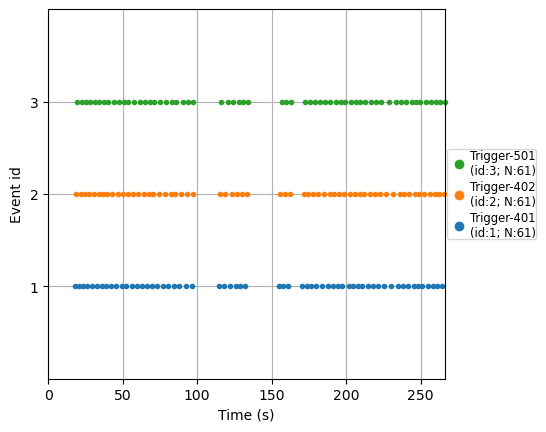

In [7]:
# Extracting Events
def get_events_from_epochs(epochs):
    """
    Retrieve events and event IDs from an mne.Epochs object.
    
    Parameters:
    - epochs: An mne.Epochs object.
    
    Returns:
    - events: The events array (shape: n_events x 3).
    - event_id: A dictionary mapping event names to event IDs.
    """
    events = epochs.events  # Shape: (n_events, 3)
    event_id = epochs.event_id  # Dictionary: {event_name: event_code}
    return events, event_id

# Retrieve events for each epochs file
for i, epochs in enumerate(epochs):
    print(f"File {i + 1}:")
    events, event_id = get_events_from_epochs(epochs)
    print(f"  Events shape: {events.shape}")
    print(f"  Event IDs: {event_id}")



# Extract events 

event1 = 'Trigger-401'
event2 = 'Trigger-402'
event3 = 'Trigger-501'

sfreq = epochs.info['sfreq']


fig = mne.viz.plot_events(events, sfreq=sfreq, event_id=event_id);

In [8]:
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501']  # Example event conditions

### **Band Power Calculation**

In [9]:
FREQ_BANDS = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 150),
}


In [10]:
def compute_psd(epochs, fmin=1, fmax=150, method="welch"):
    """
    Compute PSD using Welch's or Multitaper method for all epochs.
    """
    psd = epochs.compute_psd(method=method, fmin=fmin, fmax=fmax)
    psd_data, freqs = psd.get_data(return_freqs=True)  # Shape: (n_epochs, n_channels, n_freqs)
    return psd_data, freqs

In [11]:
def process_subject(subject_id, bands, reshaped_data, save_dir=SAVE_DIR):
    """
    Process all `.fif` files for a subject, compute PSD, and reshape the data without averaging epochs.
    """
    # Load all epochs for the subject
    epochs_list = load_epochs(subject_id, save_dir)

    # Process each `.fif` file (each representing an event type)
    for event_id, epochs in enumerate(epochs_list, start=1):
        ch_names = epochs.ch_names
        events, event_id_dict = get_events_from_epochs(epochs)

        # Check for missing triggers
        missing_triggers = False
        for condition in event_conditions:
            if condition not in event_id_dict:
                print(f"Warning: '{condition}' not found for subject {subject_id}. Skipping.")
                missing_triggers = True
        if missing_triggers:
            continue
        
        # Compute PSD (n_epochs, n_channels, n_freqs)
        psd_data, freqs = compute_psd(epochs)

        # Compute band PSD for each epoch
        band_psd_df = compute_band_psd(psd_data, freqs, bands, ch_names)

        # Add metadata
        band_psd_df["Event"] = event_id
        band_psd_df["Subject"] = subject_id

        # Create electrode-band features
        band_psd_df["Feature"] = band_psd_df["Electrode"] + " x " + band_psd_df["Band"]

        # Pivot to wide format (one row per epoch)
        wide_format = band_psd_df.pivot_table(
            index=["Subject", "Event", "Epoch"], 
            columns="Feature", 
            values="Power"
        ).reset_index()

        reshaped_data.append(wide_format)

def compute_band_psd(psd_data, freqs, bands, ch_names):
    """
    Calculate band PSD for each epoch individually.
    Returns long-format DataFrame with columns: Epoch, Electrode, Band, Power.
    """
    n_epochs, n_channels, _ = psd_data.shape
    data = []
    
    for epoch_idx in range(n_epochs):
        for ch_idx, ch in enumerate(ch_names):
            for band, (fmin, fmax) in bands.items():
                band_indices = np.where((freqs >= fmin) & (freqs < fmax))[0]
                power = np.nan
                if len(band_indices) > 0:
                    # Average across frequencies in the band
                    power = psd_data[epoch_idx, ch_idx, band_indices].mean()
                
                data.append({
                    'Epoch': epoch_idx,
                    'Electrode': ch,
                    'Band': band,
                    'Power': power
                })
    
    return pd.DataFrame(data)

In [12]:
# Get the list of subject directories
save_path = Path(SAVE_DIR)
subject_dirs = [item.name for item in save_path.iterdir() if item.is_dir()]

# Set the subject
print(f"Subjects found in '{SAVE_DIR}': {len(subject_dirs)}")
print(subject_dirs)

Subjects found in 'processed_epochs': 1
['sub-01']


In [13]:
# --- Main Processing Loop ---

subject_ids = ['sub-01']
sfreq = epochs.info["sfreq"]
reshaped_data = []

for subject_id in subject_ids:
    process_subject(subject_id, FREQ_BANDS, reshaped_data, save_dir=SAVE_DIR)

# Combine all reshaped data
psd_df = pd.concat(reshaped_data, ignore_index=True)

# Handle missing values (optional)
#psd_df = final_reshaped_df.dropna(how="any", axis=1)  # Drop columns with NaN

Loaded: sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 66 channels
Loaded: sub-01_ses-02_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 11 channels
Loaded: sub-01_ses-03_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 58 channels
⚠️ Warning: Some channels are missing across sessions: 129
✅ Successfully loaded 3 separate epochs objects.


In [14]:
psd_df

Feature,Subject,Event,Epoch,POL DC01 x Alpha,POL DC01 x Beta,POL DC01 x Delta,POL DC01 x Gamma,POL DC01 x Theta,POL DC02 x Alpha,POL DC02 x Beta,POL DC02 x Delta,POL DC02 x Gamma,POL DC02 x Theta
0,sub-01,1,0,4.468912e-08,2.863666e-07,1.839612e-08,7.689466e-06,1.014183e-08,1.843539e-09,1.438798e-09,1.847851e-09,1.754915e-08,7.828963e-10
1,sub-01,1,1,4.271138e-08,4.899206e-07,4.842449e-10,1.655343e-07,9.675113e-09,1.413984e-09,2.719842e-09,1.643586e-09,1.734013e-08,5.598331e-10
2,sub-01,1,2,1.507455e-06,8.766890e-07,2.583198e-07,1.264765e-05,1.073716e-06,4.142656e-09,2.466395e-09,4.673533e-10,1.836529e-08,6.480141e-10
3,sub-01,1,3,1.881763e-08,1.203626e-07,1.440010e-09,8.994226e-06,5.207995e-09,1.929901e-09,2.507742e-09,5.034666e-09,1.934383e-08,1.591477e-09
4,sub-01,1,4,6.105277e-07,1.728533e-06,1.878990e-08,7.141162e-06,1.846420e-07,2.467450e-09,1.992893e-09,2.711065e-09,1.844407e-08,6.611419e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,sub-01,3,178,1.020450e-06,5.909462e-06,1.845323e-07,4.859515e-05,1.184106e-06,5.420212e-09,1.220043e-09,6.188739e-10,1.897764e-08,4.297140e-09
545,sub-01,3,179,4.535089e-08,2.832727e-07,5.771747e-09,8.910202e-07,1.143683e-08,2.881455e-09,2.327909e-09,8.970734e-10,2.061204e-08,1.949729e-09
546,sub-01,3,180,1.225556e-07,1.494883e-06,1.494966e-08,5.745558e-06,1.061560e-07,6.652215e-10,2.316205e-09,4.711429e-10,1.903094e-08,1.263555e-09
547,sub-01,3,181,5.958077e-08,1.830106e-07,1.787285e-09,6.169418e-07,1.167793e-08,2.265979e-09,2.924608e-09,4.757759e-10,1.894054e-08,2.193470e-09


### **Electrode positions**

In [15]:
# Load electrode metadata
electrodes_tsv = 'ds005545-download/sub-80/ses-01/ieeg/sub-80_ses-01_electrodes.tsv'
electrode_positions = pd.read_csv(electrodes_tsv, sep='\t')

# Display electrode positions
print(electrode_positions.head())

  name          x          y          z  size
0   A3 -50.106579 -58.395985  23.277752     0
1   A4 -59.254402 -54.785877  15.215353     0
2   A5 -59.978233 -40.066578  39.257343     0
3   A6 -45.325970 -28.038254  37.129173     0
4   A7 -54.598400 -25.692129  44.675392     0


In [16]:
from mne.datasets import fetch_fsaverage
from mne.transforms import Transform, apply_trans


# Prepare electrode positions for MNE montage
elec_names = electrode_positions['name'].values.tolist()  # Convert to a list
elec_positions = electrode_positions[['x', 'y', 'z']].values / 1000  # Convert from mm to meters

# Define fiducial points for head coordinates (replace with actual positions in meters)
fiducials = {
    'nasion': np.array([0, 0.1, 0]),
    'lpa': np.array([-0.1, 0, 0]),
    'rpa': np.array([0.1, 0, 0]),
}

# Combine fiducial and electrode positions
ch_pos = {name: pos for name, pos in zip(elec_names, elec_positions)}
ch_pos.update(fiducials)  # Add fiducials to channel positions

# Create a montage with fiducials
montage = mne.channels.make_dig_montage(
    ch_pos=ch_pos,
    coord_frame='head'  # Use 'head' as the coordinate frame
)

# Create an `info` object for the electrodes
info = mne.create_info(
    ch_names=elec_names,
    sfreq=1000,  # Replace with your sampling frequency
    ch_types="seeg"  # Specify the channel type
)
info.set_montage(montage)  # Set the montage to the info object

# Fetch fsaverage template for visualization
sample_path = mne.datasets.sample.data_path()
subjects_dir = sample_path / "subjects"
fetch_fsaverage(subjects_dir=subjects_dir, verbose=True)

# Perform coregistration to compute head->MRI transform
trans = mne.transforms.Transform(
    fro="head", to="mri", trans=np.eye(4)  # Identity matrix as a placeholder
)  # Replace with a valid coregistration matrix if available

# Visualize electrode positions on fsaverage
brain = mne.viz.Brain(
    "fsaverage",
    subjects_dir=subjects_dir,
    cortex="low_contrast",
    alpha=0.25,
    background="white",
)

# Add electrodes to the brain visualization
brain.add_sensors(info, trans=trans)  # Use the computed transformation

# Show the view
brain.show_view(azimuth=120, elevation=100, distance=400)

# **Apply the Transformation to the Montage (Important Step)**
# Extract the electrode positions
ch_pos = montage.get_positions()['ch_pos']

# Apply the head-to-MRI transform to each electrode
transformed_positions = {}
for ch_name, pos in ch_pos.items():
    # Apply the transformation to each electrode position
    transformed_pos = apply_trans(trans['trans'], pos)
    transformed_positions[ch_name] = transformed_pos

# Update the montage with the transformed positions
montage = mne.channels.make_dig_montage(
    ch_pos=transformed_positions,
    coord_frame='mri'  # Update the coordinate frame to 'mri'
)

# **Now, Get Volume Labels**
# Map electrode positions to anatomical regions
labels, colors = mne.get_montage_volume_labels(
    montage, "fsaverage", subjects_dir=subjects_dir, aseg="aparc+aseg"
)



c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


0 files missing from root.txt in C:\Users\lacom\mne_data\MNE-sample-data\subjects
0 files missing from bem.txt in C:\Users\lacom\mne_data\MNE-sample-data\subjects\fsaverage
False


In [17]:
# Accessing and indexing epochs by condition
evoked_1 = epochs['Trigger-401'].average()
evoked_2 = epochs['Trigger-402'].average()

C:\Users\lacom\AppData\Local\Temp\ipykernel_16212\1749978461.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')


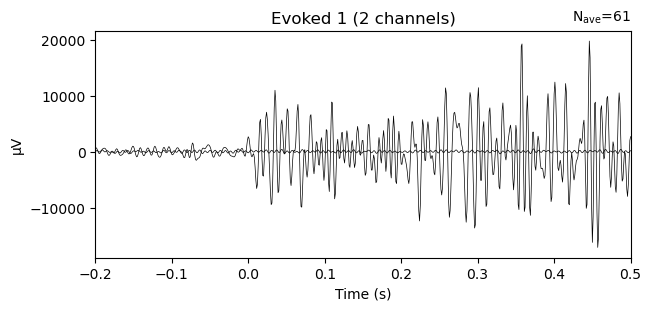

C:\Users\lacom\AppData\Local\Temp\ipykernel_16212\1749978461.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')


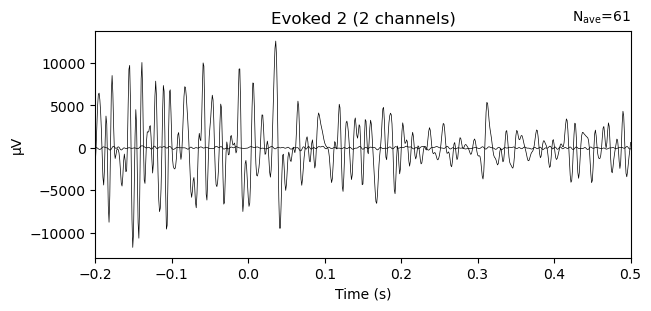

In [18]:
fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')
fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')

### Machine Learning

In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore

In [23]:
# Define the event conditions you want to label
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501'] 

#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
Trigger1_epochs = epochs['Trigger-401']
Trigger2_epochs = epochs['Trigger-402']

# Print information about the equalized epochs
print(Trigger1_epochs)
print(Trigger2_epochs)

<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~677 KiB, data loaded,
 'Trigger-401': 61>
<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~677 KiB, data loaded,
 'Trigger-402': 61>


In [26]:
psd_df.columns

Index(['Subject', 'Event', 'Epoch', 'POL DC01 x Alpha', 'POL DC01 x Beta',
       'POL DC01 x Delta', 'POL DC01 x Gamma', 'POL DC01 x Theta',
       'POL DC02 x Alpha', 'POL DC02 x Beta', 'POL DC02 x Delta',
       'POL DC02 x Gamma', 'POL DC02 x Theta'],
      dtype='object', name='Feature')

In [31]:
# Original labels: [1, 2, 3] → Desired labels: [0, 1, 2]
remap_dict = {1: 0, 2: 1, 3: 2}

In [32]:
# Step 0: Prepare the data
psd_df['Event'] = psd_df['Event'].map(remap_dict).astype(int)  # Explicit remapping

In [33]:
print("Original labels:", psd_df['Event'].unique())

Original labels: [0 1 2]


In [34]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

features = ['POL DC01 x Alpha', 'POL DC01 x Beta',
       'POL DC01 x Delta', 'POL DC01 x Gamma', 'POL DC01 x Theta',
       'POL DC02 x Alpha', 'POL DC02 x Beta', 'POL DC02 x Delta',
       'POL DC02 x Gamma', 'POL DC02 x Theta']


X = psd_df[features]  # Features (drop the label column)
y = psd_df['Event']  # Labels

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [35]:

# Step 2: Define the best hyperparameters based on grid search results
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

# Step 3: Set up the XGBoost classifier with the best hyperparameters
xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    **best_params  # Apply the best hyperparameters here
)

# Step 4: Fit the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = xgb.predict(X_test)

# Step 6: Evaluate the model performance using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with best hyperparameters: {accuracy:.4f}")


c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:31:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy with best hyperparameters: 0.0182


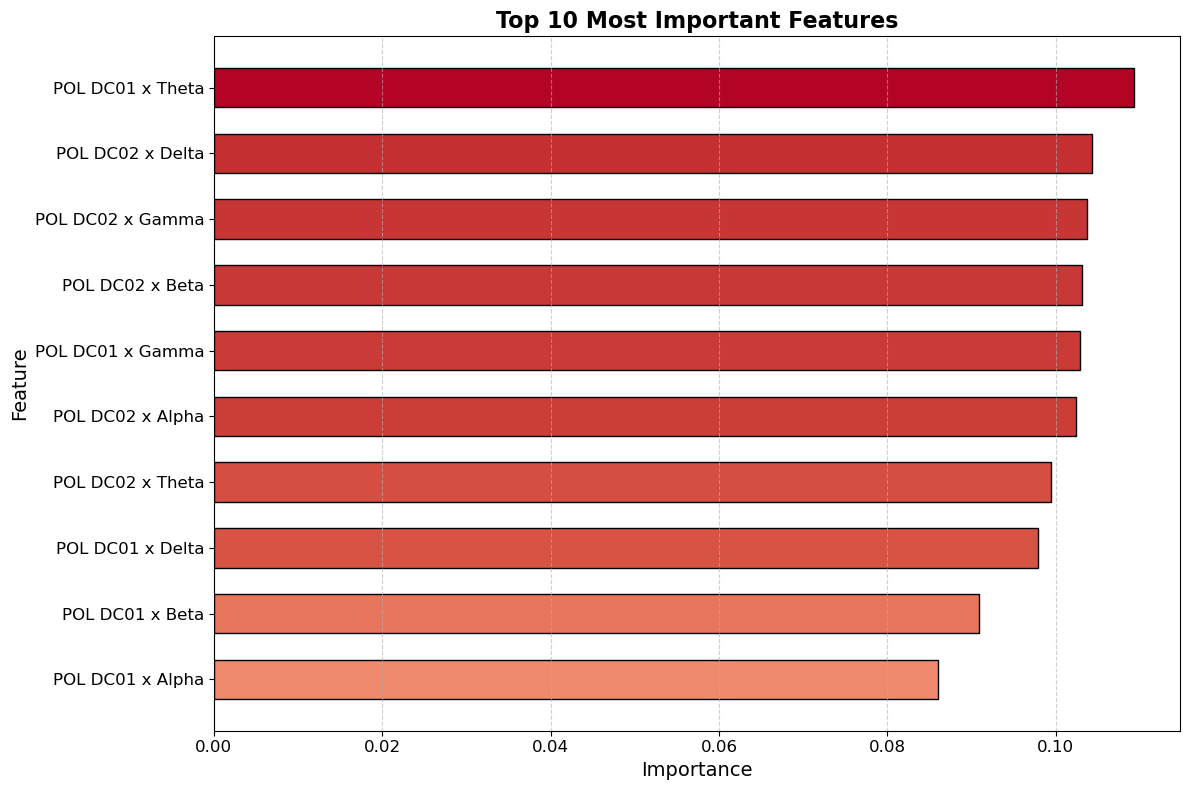

,feature,importance
4,POL DC01 x Theta,0.109300
7,POL DC02 x Delta,0.104343
8,POL DC02 x Gamma,0.103692
6,POL DC02 x Beta,0.103178
3,POL DC01 x Gamma,0.102870
5,POL DC02 x Alpha,0.102383
9,POL DC02 x Theta,0.099457
2,POL DC01 x Delta,0.097893
1,POL DC01 x Beta,0.090846
0,POL DC01 x Alpha,0.086039


In [36]:
# Get feature importance from the trained model
importances = xgb.feature_importances_

# Step 10: Create a DataFrame of feature importances (with channel-timepoint as the feature names)
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top 10 most important features
top_10_features = feature_importances_df.head(10)

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a color palette based on importance values (from light to dark)
bar_colors = sns.color_palette("coolwarm", as_cmap=True)

# Create the horizontal bar plot
bars = plt.barh(top_10_features['feature'], top_10_features['importance'], 
                color=bar_colors(top_10_features['importance'] / max(top_10_features['importance'])), 
                edgecolor='black', height=0.6)


# Make the title and labels more readable
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Invert the y-axis to display the most important feature at the top
plt.gca().invert_yaxis()

# Customize the grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Step 12: Optionally, output the top important features for further analysis
top_10_features
